## Evaluate Tuning Results Based on Validation Data Set

to create Figure C1 and Tables C1 & C2

In [1]:
import os
import json
import sys

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2


MODE = 'val'  # use validation set!

In [ ]:
data_dir = os.path.sep.join([base_dir, 'data', 'processed', 'HIRHAM5-ERAInterim', 'v_02'])

train_test_split_file = 'train_val_test_split_100.json'
train_val_test_indices = json.load(open(os.path.sep.join([data_dir, train_test_split_file])))
valtest_indices = train_val_test_indices[MODE]

### Load Climatology (1990-2013) as baseline

In [3]:
interim_dir = os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack'])
clim_melt = xr.open_dataset(os.path.sep.join([interim_dir, 'climat_1990-2013_smoothed15.nc']))['snmel']
clim_melt_z = clim_melt.stack(z=('x', 'y')).reset_index('z').dropna('z', how='any')

In [5]:
# load base dataset
data_dir = os.path.sep.join([base_dir, 'data', 'processed', 'HIRHAM5-ERAInterim', 'v_02'])
ds = xr.open_zarr(os.path.sep.join([data_dir, f'base_dataset.zarr']), chunks='auto')
ds = ds.sel(time=valtest_indices)
ds_melt_z = ds['snmel']
ds_melt = ds_melt_z.set_index(z=['y', 'x']).unstack('z')

In [6]:
# Calculate daily anomalies of true validation data w.r.t. the climatology
md_clim = clim_melt_z['time'].dt.strftime('%m-%d')
clim_melt_z = clim_melt_z.assign_coords(md=md_clim)
clim_by_md = clim_melt_z.groupby('md').mean(dim='time')
md_data = ds_melt_z['time'].dt.strftime('%m-%d')
ds_melt_z = ds_melt_z.assign_coords(md=('time', md_data.values))
anomaly = clim_by_md - ds_melt_z.groupby('md')
anoms_val_z = anomaly.compute()
anoms_val = anoms_val_z.set_index(z=['y', 'x']).unstack('z')

### Performance of Climatology as Model

In [7]:
# climatological anomaly per location of valdiation
print(f'GrIS:')
gris_scores = {'rmse': get_rmse(anoms_val_z, 2),
               'mae': get_mae(anoms_val_z, 2),
               'mbe': get_mbe(anoms_val_z, 4)}
               
print(f'RMSE: {gris_scores["rmse"]}')
print(f'MAE: {gris_scores["mae"]}')
print(f'MBE: {gris_scores["mbe"]}')

GrIS:
RMSE: 2.22
MAE: 0.53
MBE: -0.0533


## Compare all tuning trials

In [11]:
# for each set-up need mae_rate+mbe_rate (i.e. sum of MAE and MBE relative to MAE and MBE from climatolgy) 
out_dir = os.path.sep.join([base_dir, 'output'])

configs = ['regression', 'modularNN', 'shorttermNN', 'autoreg1noise', 
           'modularNN_multitarget', 'modularNN_multitarget_trainable', 
           'modularNN_EBMTd', 'modularNN_EBMT', 
           'modularNN_EBM', 'modularNN_EBS', 'modularNN_EBR',
           'modularNN_EBMnodoy']

# configs = ['modularNN_wotasdoy']

scores_overview = {}

# # make files with relative scores
# for modelname in configs:
#     if modelname == 'autoreg1noise':
#         inf_values = ['', '_auto']  # '' refers to teacher-forced, '_auto' to inference mode
#     else:
#         inf_values = ['']
#     for inf in inf_values:
#         model_dir = os.path.sep.join([out_dir, f'optuna_melt_{modelname}'])
#         scores_modular = pd.read_csv(os.path.sep.join([model_dir, f'scores{inf}_{MODE}.csv']))
#         scores_modular['rmse_rate'] = scores_modular['rmse'] / gris_scores["rmse"]
#         scores_modular['mae_rate'] = scores_modular['mae'] / gris_scores["mae"]
#         scores_modular['mbe_rate'] = scores_modular['mbe'] / np.abs(gris_scores["mbe"])
#         scores_modular['mae+mbe_rate'] = np.abs(scores_modular['mae_rate']) + np.abs(scores_modular['mbe_rate'])
#         scores_modular.sort_values('mae+mbe_rate', inplace=True)
#         save_dir = os.path.sep.join([model_dir, f'score_rates{inf}_'+MODE+'.csv'])
#         print(f'Saving scores rates to {save_dir}')
#         scores_modular.to_csv(save_dir, index=False)
#         scores_overview[f'{modelname}{inf}'] = scores_modular


# read the overview files
for modelname in configs:
    if modelname == 'autoreg1noise':
        inf_values = ['', '_auto']
    else:
        inf_values = ['']
    for inf in inf_values:
        model_dir = os.path.sep.join([out_dir, f'optuna_melt_{modelname}'])
        scores_overview[f'{modelname}{inf}'] = pd.read_csv(os.path.sep.join([model_dir, f'score_rates{inf}_{MODE}.csv']), index_col=0)
        print(f'Best models for config: {modelname}{inf}')
        display(scores_overview[f'{modelname}{inf}'].head())

Best models for config: regression


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
0,1.477741,0.341831,0.052677,0.665649,0.644964,0.988311,1.633275
4,1.467088,0.353441,0.056629,0.660850,0.666870,1.062453,1.729322
5,1.469800,0.356014,0.062701,0.662072,0.671724,1.176372,1.848096
1,1.468925,0.347256,0.064844,0.661678,0.655201,1.216585,1.871786
2,1.494749,0.365251,0.067964,0.673310,0.689153,1.275116,1.964269


Best models for config: modularNN


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
21,0.857585,0.155213,0.001532,0.386299,0.292855,0.028750,0.321606
6,0.858485,0.162048,0.001877,0.386705,0.305751,0.035225,0.340975
41,0.854369,0.150285,-0.003370,0.384851,0.283556,-0.063228,0.346784
35,0.843150,0.156256,0.003145,0.379797,0.294822,0.059000,0.353822
3,0.851017,0.158443,0.004464,0.383341,0.298948,0.083759,0.382707


Best models for config: shorttermNN


...

,rmse,mae,mbe,r2,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,,
9,0.807505,0.142279,0.000042,0.969134,0.363741,0.268451,0.000795,0.269246
21,0.809441,0.140342,0.000318,0.968986,0.364613,0.264797,0.005959,0.270756
10,0.819788,0.149926,-0.000899,0.968188,0.369274,0.282880,-0.016872,0.299752
7,0.834812,0.152637,-0.001059,0.967011,0.376041,0.287995,-0.019875,0.307870
11,0.817923,0.150120,0.001489,0.968332,0.368434,0.283245,0.027927,0.311172


Best models for config: modularNN_EBR


,rmse,mae,mbe,r2,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,,
22,1.122583,0.222595,-0.001911,0.940347,0.505668,0.419991,-0.035855,0.455845
13,1.124067,0.217877,-0.003452,0.940189,0.506337,0.411088,-0.064760,0.475848
19,1.124625,0.215940,0.007412,0.940130,0.506588,0.407433,0.139056,0.546490
6,1.138401,0.225682,0.011430,0.938654,0.512793,0.425815,0.214446,0.640261
24,1.135667,0.223449,0.011832,0.938949,0.511562,0.421602,0.221991,0.643593


Best models for config: modularNN_EBMnodoy


,rmse,mae,mbe,r2,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,,
21,0.893875,0.159345,0.000504,0.962178,0.402646,0.300650,0.009459,0.310110
22,0.885638,0.163128,0.000129,0.962872,0.398936,0.307789,0.002419,0.310208
5,0.891320,0.160178,-0.000851,0.962394,0.401496,0.302223,-0.015960,0.318182
8,0.877394,0.166425,0.000912,0.963560,0.395223,0.314009,0.017107,0.331116
31,0.880539,0.154304,-0.005938,0.963298,0.396639,0.291139,-0.111414,0.402554


## Tuning Evaluation

Best Regression NN: trial 0 with MAE=0.3418308351255243, MBE=0.0526769771855031
Best Short-term NN: trial 28 with MAE=0.2224381601515297, MBE=-0.0008041217723275
Best Autoreg NN (teacher): trial 19 with MAE=0.0572420925186628, MBE=-0.0006145100886095
Best Autoreg NN (inference): trial 18 with MAE=0.136568054926026, MBE=5.647650613956333e-05
Best Modular NN: trial 21 with MAE=0.1552133462035758, MBE=0.0015323939151699


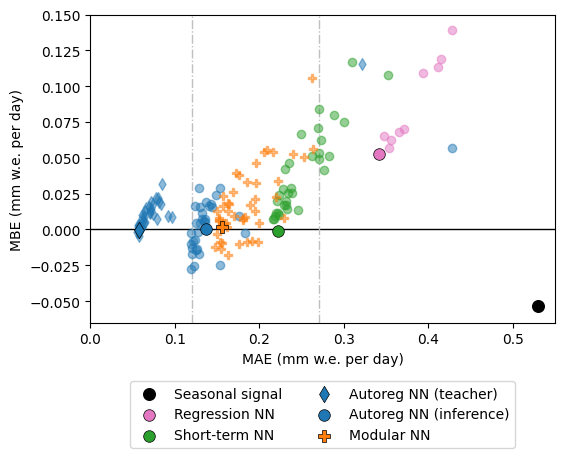

In [ ]:
# Figure C1a: Scatter plot of MAE vs MBE for all tuning trials of model configurations
cmap = mcolors.ListedColormap(cc.glasbey_category10)

plot_configs = {'regression':'Regression NN', 
                'shorttermNN': 'Short-term NN', 
                'autoreg1noise': 'Autoreg NN (teacher)', 
                'autoreg1noise_auto': 'Autoreg NN (inference)',
                'modularNN':'Modular NN', 
                }
colors = [cmap.colors[i] for i in [6,2,0,0,1]]

fig, ax = plt.subplots(figsize=(6,4))
ax.hlines(0, .0, .55, color='k', linewidth=1., zorder=0)
ax.scatter(gris_scores['mae'], gris_scores['mbe'], label='Seasonal signal', marker='o', color='k', s=70)
plt.axvline(x=0.12,color='silver', linewidth=1., linestyle='-.', zorder=0)
plt.axvline(x=0.27,color='silver', linewidth=1., linestyle='-.', zorder=0)

for i, (model, label) in enumerate(plot_configs.items()):
    df = scores_overview[model]
    df = df[df['mae']<0.6]  # add extra filtering, since there are two very bad tuning trials for modular NN
    
    df_best = df.loc[df['mae+mbe_rate'].idxmin()]
    print(f'Best {label}: trial {df_best.name} with MAE={df_best["mae"]}, MBE={df_best["mbe"]}')
    marker='d' if 'teacher' in label else ('P' if 'Modular' in label else 'o') 
    ax.scatter(df['mae'], df['mbe'], marker=marker, alpha=0.5, color=colors[i])
    ax.scatter(df_best['mae'], df_best['mbe'], label=label, marker=marker, edgecolor='k', linewidth=.5, color=colors[i], s=70, zorder=42)

ax.set_xlabel('MAE (mm w.e. per day)')
ax.set_ylabel('MBE (mm w.e. per day)')
plt.legend(ncols=2, bbox_to_anchor=(0.07, -.43), loc='lower left')

ax.set_xlim(0, 0.55)
ax.set_ylim(-0.065, 0.15)

fig.savefig(os.path.sep.join([base_dir, 'figures', 'tuning_scores_configs.png']), bbox_inches='tight', dpi=300)
plt.show()

Best Modular NN: trial 21 with MAE=0.1552133462035758, MBE=0.0015323939151699
Best Modular EBMT$_d$: trial 22 with MAE=0.147886030461931, MBE=0.0005988449368562
Best Modular EBMT: trial 18 with MAE=0.1379923709211045, MBE=-0.0010154352372527
Best Modular EBM: trial 13 with MAE=0.1377938394814633, MBE=0.0009413648497547
Best Modular EBS: trial 9 with MAE=0.1422790091963207, MBE=4.237195723651661e-05
Best Modular EBR: trial 22 with MAE=0.2225949868726599, MBE=-0.0019110480273627
Best Modular EBM$_{noDOY}$: trial 21 with MAE=0.1593446687974558, MBE=0.0005041753136209


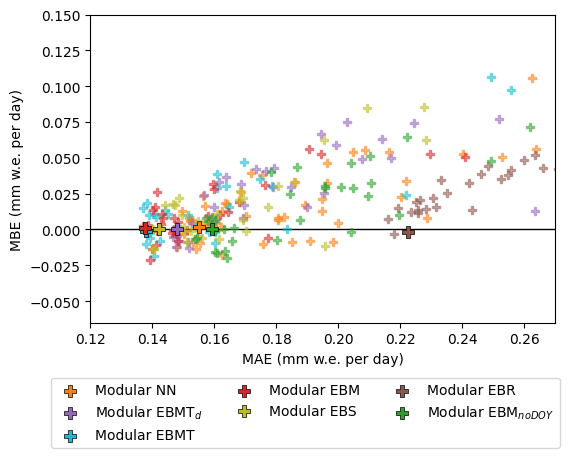

In [ ]:
# Figure C1b: Scatter plot of MAE vs MBE for all tuning trials of model configurations
cmap = mcolors.ListedColormap(cc.glasbey_category10)

plot_configs = {
                'modularNN':'Modular NN', 
                'modularNN_EBMTd': r'Modular EBMT$_d$',
                'modularNN_EBMT': 'Modular EBMT',
                'modularNN_EBM': 'Modular EBM',
                'modularNN_EBS': 'Modular EBS',
                'modularNN_EBR': 'Modular EBR',
                'modularNN_EBMnodoy': 'Modular EBM$_{noDOY}$'
                }

colors = [cmap.colors[i] for i in [1,4,9,3,8,5,2]]

fig, ax = plt.subplots(figsize=(6,4))
ax.hlines(0, .0, .55, color='k', linewidth=1., zorder=0)

for i, (model, label) in enumerate(plot_configs.items()):
    df = scores_overview[model]
    df = df[df['mae']<0.6]
    
    df_best = df.loc[df['mae+mbe_rate'].idxmin()]
    print(f'Best {label}: trial {df_best.name} with MAE={df_best["mae"]}, MBE={df_best["mbe"]}')
    marker='d' if 'teacher' in label else ('P' if 'Modular' in label else 'o') 
    ax.scatter(df['mae'], df['mbe'], marker=marker, alpha=0.5, color=colors[i])
    ax.scatter(df_best['mae'], df_best['mbe'], label=label, marker=marker, edgecolor='k', linewidth=.5, color=colors[i], s=70, zorder=42)

ax.set_xlabel('MAE (mm w.e. per day)')
ax.set_ylabel('MBE (mm w.e. per day)')
plt.legend(ncols=3, bbox_to_anchor=(-0.1, -.43), loc='lower left')

ax.set_xlim(0.12, 0.27)
ax.set_ylim(-0.065, 0.15)

fig.savefig(os.path.sep.join([base_dir, 'figures', 'tuning_scores_modular.png']), bbox_inches='tight', dpi=300)
plt.show()